In [8]:
import os
import glob
import random
import cv2
import json
from PIL import Image
import numpy as np
import decord
import matplotlib.pyplot as plt

In [9]:
abs_dir = 'D:/OneDrive - Hanoi University of Science and Technology/Domain Basics/Introduction to Deep Learning/Data/train/samples'
data_paths = glob.glob(abs_dir+'/*')

In [10]:
annotation_path = os.path.join(abs_dir.split('/samples')[0], 'annotations/annotations.json')
with open(annotation_path, 'r') as f:
    json_data = json.load(f)
annotation = json_data

10466
4500
5085
5221
5142
5163
4697
6675
6410
4886
5609
5103
4998
6774
All Videos: Total Frames: 80729, Total Annotations: 20106


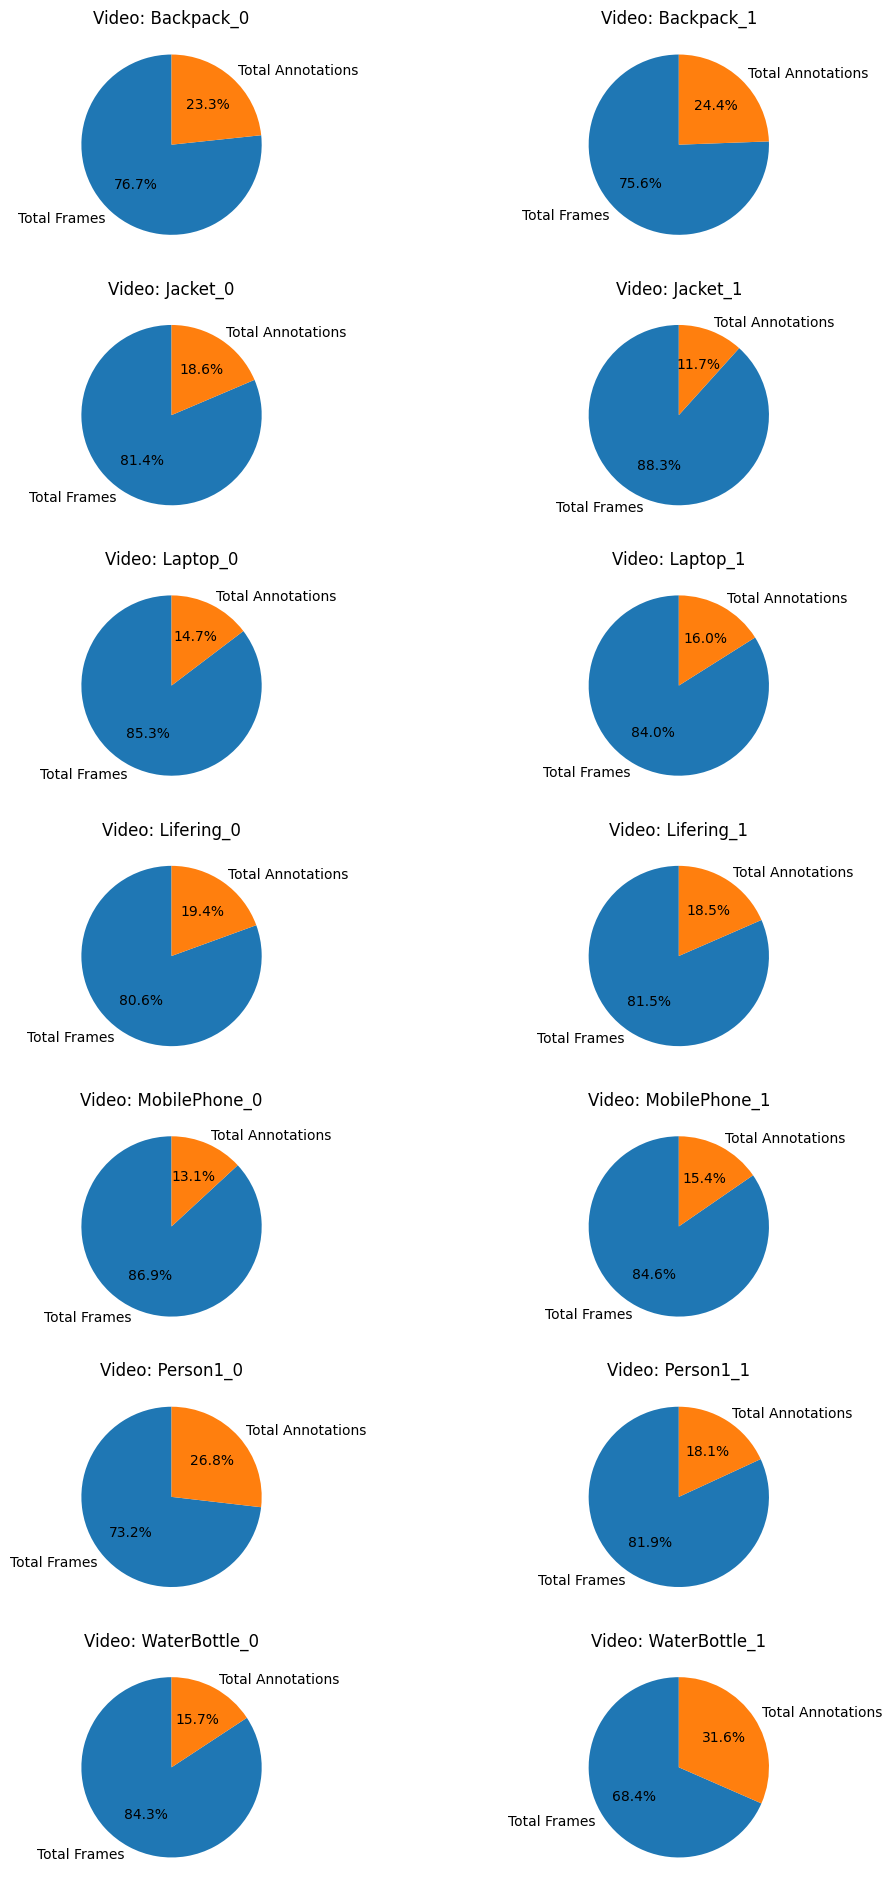

In [12]:
all_frames = 0
all_annotations = 0

fig, ax = plt.subplots(7, 2, figsize=(12, 24))

for i, data_path in enumerate(data_paths):
    object_name = data_path.split('\\')[-1]
    clip_path = glob.glob(os.path.join(data_path, '*.mp4'))[0]
    cap = cv2.VideoCapture(clip_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    bboxes = {}

    for video in annotation:
        if video['video_id'] != object_name:
            continue
        else:
            annotations = video['annotations']
            for bbox in annotations:
                bbox_info = bbox['bboxes']
                for frame in bbox_info:
                    bboxes[int(frame['frame'])] = [int(frame['y1']), int(frame['x1']), int(frame['y2']), int(frame['x2'])]
    labels = ['Total Frames', 'Total Annotations']
    sizes = [total_frames, len(bboxes)]
    ax[i // 2, i % 2].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax[i // 2, i % 2].set_title(f'Video: {object_name}')
    
    all_frames += total_frames
    print(total_frames)
    all_annotations += len(bboxes)

print(f'All Videos: Total Frames: {all_frames}, Total Annotations: {all_annotations}')

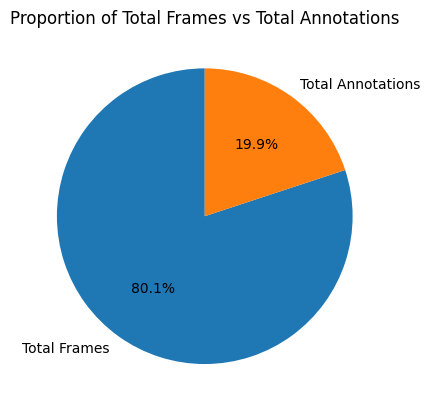

In [5]:
# Draw pie chart of total frames vs total annotations
import matplotlib.pyplot as plt
labels = ['Total Frames', 'Total Annotations']
sizes = [all_frames, all_annotations]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Total Frames vs Total Annotations')
plt.show()

In [6]:
def visualize_sample(annotation, data_path):
    object_name = data_path.split('\\')[-1]
    clip_path = glob.glob(os.path.join(data_path, '*.mp4'))[0]
    cap = cv2.VideoCapture(clip_path)
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    bboxes = {}
    
    for video in annotation:
        if video['video_id'] != object_name:
            continue
        else:
            annotations = video['annotations']
            for bbox in annotations:
                bbox_info = bbox['bboxes']
                for frame in bbox_info:
                    bboxes[int(frame['frame'])] = [int(frame['y1']), int(frame['x1']), int(frame['y2']), int(frame['x2'])]

    out = cv2.VideoWriter('output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    frame_id = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_id in bboxes:
            y1, x1, y2, x2 = bboxes[frame_id]
            label = object_name.split('_')[0]
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(
                frame,
                label,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )
        cv2.imshow('', frame)
        out.write(frame)
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break
        frame_id += 1
    cap.release()
    out.release()
    cv2.destroyAllWindows()

In [ ]:
visualize_sample(annotation, data_paths[1])